**Updated Cell 1 — Configuration**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde
from arch import arch_model

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

PORTFOLIO_CSV = os.path.join(BASE_DIR, "DE_portfolio_log_returns.csv")
INNOVATIONS_CSV = os.path.join(BASE_DIR, "DE_portfolio_garch_innovations.csv")

**Updated Cell 2 — Load full portfolio series**

In [2]:
raw = pd.read_csv(PORTFOLIO_CSV, index_col=0, parse_dates=True)
r_portfolio = raw.iloc[:, 0]
r_portfolio.index.name = "Date"

if r_portfolio.empty:
    raise RuntimeError(f"No data found in {PORTFOLIO_CSV}")

print(r_portfolio.head())
print(r_portfolio.tail())
print("Observations:", len(r_portfolio))
print("Date range:", r_portfolio.index.min(), "to", r_portfolio.index.max())

Date
1996-12-17   -0.022351
1996-12-18    0.014396
1996-12-19    0.000293
1996-12-20    0.019498
1996-12-23    0.001906
Name: Log_returns, dtype: float64
Date
2026-04-27    0.034596
2026-04-28   -0.048969
2026-04-29   -0.045270
2026-04-30    0.070824
2026-05-04   -0.025886
Name: Log_returns, dtype: float64
Observations: 7522
Date range: 1996-12-17 00:00:00 to 2026-05-04 00:00:00


**Cell 3 — Fit GARCH(1,1) and compute innovations**

In [3]:
if os.path.exists(INNOVATIONS_CSV):
    print(f"File already exists, skipping GARCH fit: {INNOVATIONS_CSV}")
    epsilon_t = pd.read_csv(INNOVATIONS_CSV, index_col=0, parse_dates=True).iloc[:, 0]
else:
    garch = arch_model(r_portfolio, vol='Garch', p=1, q=1, mean='Zero')
    res = garch.fit(disp='off')

    sigma_t = res.conditional_volatility
    epsilon_t = (r_portfolio / sigma_t).dropna()
    epsilon_t.name = "epsilon_t"
    epsilon_t.to_csv(INNOVATIONS_CSV)
    print(f"GARCH innovations saved to {INNOVATIONS_CSV}")

print(epsilon_t.head())

GARCH innovations saved to ../Data/DE_portfolio_garch_innovations.csv
Date
1996-12-17   -0.843112
1996-12-18    0.539548
1996-12-19    0.011093
1996-12-20    0.751218
1996-12-23    0.073276
Name: epsilon_t, dtype: float64


/opt/anaconda3/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.002642. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


**Cell 4 — Reload innovations from disk**

In [4]:
epsilon_t = pd.read_csv(INNOVATIONS_CSV, index_col=0, parse_dates=True).iloc[:, 0]
x = epsilon_t.values

**Cell 5 — Compute kernel density and log-density**

In [5]:
kde = gaussian_kde(x, bw_method='silverman')
x_grid = np.linspace(x.min(), x.max(), 500)
kde_vals = kde(x_grid)
normal_vals = norm.pdf(x_grid, 0, 1)

eps_const = 1e-10
log_kde_vals = np.log(kde_vals + eps_const)
log_normal_vals = np.log(normal_vals + eps_const)

**Cell 6 — Plot density, display and save**

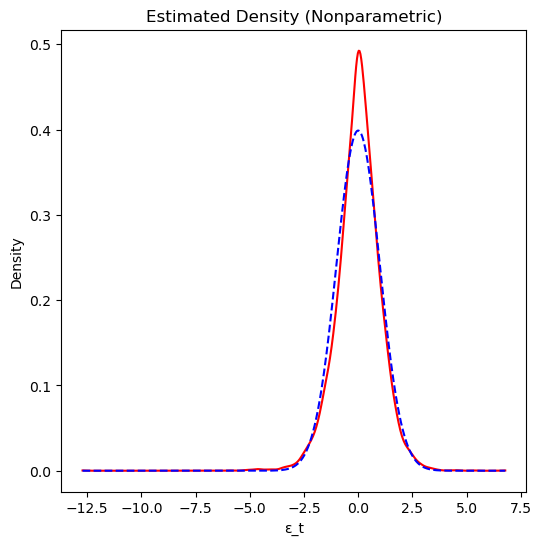

In [8]:
plt.figure(figsize=(6, 6))
plt.plot(x_grid, kde_vals, color='red', label='GARCH innovations (data)')
plt.plot(x_grid, normal_vals, color='blue', linestyle='--', label='N(0,1)')
plt.title("Estimated Density (Nonparametric)")
plt.xlabel("ε_t")
plt.ylabel("Density")
plt.savefig(
    os.path.join(OUTPUT_DIR, "kde_garch_innovations_density.png"),
    dpi=300, transparent=True, bbox_inches="tight"
)
plt.show()

**Cell 7 — Plot log-density, display and save**

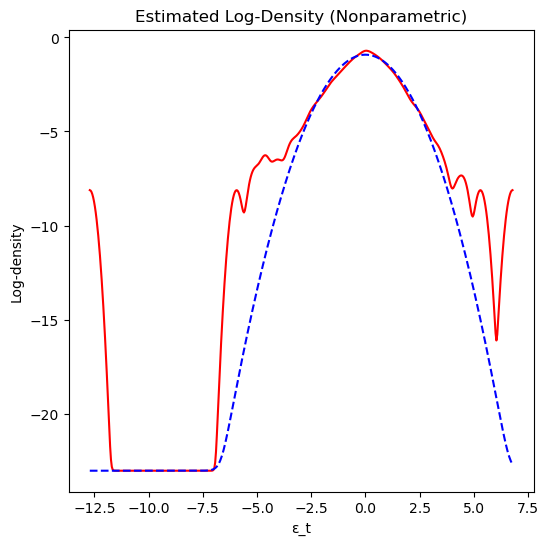

In [9]:
plt.figure(figsize=(6, 6))
plt.plot(x_grid, log_kde_vals, color='red', label='GARCH innovations (data)')
plt.plot(x_grid, log_normal_vals, color='blue', linestyle='--', label='N(0,1)')
plt.title("Estimated Log-Density (Nonparametric)")
plt.xlabel("ε_t")
plt.ylabel("Log-density")
plt.savefig(
    os.path.join(OUTPUT_DIR, "kde_garch_innovations_logdensity.png"),
    dpi=300, transparent=True, bbox_inches="tight"
)
plt.show()